<a href="https://colab.research.google.com/github/lanabrowne/OOSD-Group-30-Assignment-/blob/main/3009ICT_Group_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data Processing and Visualization
-----
**Assignment Topic: Data Analysis on Car Advertisements**


Student1 Name: Lana Browne

SNumber: s5340293

Student2 Name: ...

SNumber: ...

Student3 Name:

SNumber

# Data Import

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import sqlite3
import seaborn as sns
import matplotlib.pyplot as plt


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

car_data = pd.read_csv('/content/drive/MyDrive/car_dataset.csv')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Data Formatting

In [ ]:
## convert blank strings into missing values
car_data = car_data.replace(r"^\s*$", pd.NA, regex=True)

## a. Numerical Conversion

In [ ]:
import pandas as pd

## a. Numerical Conversion

## structure: 1. clean values 2. convert to numerical data type

# mileage: "0 Km" -> 0
car_data['mileage'] = (
    car_data['mileage']
    .str.replace(',', '', regex=False)
    .str.replace('Km', '', regex=False)
    .str.strip()
)
car_data['mileage'] = pd.to_numeric(
    car_data['mileage'],
    errors='coerce'
    )


# num_of_doors: "5-door" -> 5
car_data['num_of_doors'] = (
    car_data['num_of_doors']
    .str.replace('-door', '', regex=False)
)
car_data['num_of_doors'] = pd.to_numeric(
    car_data['num_of_doors'],
    errors='coerce'
    )


# seating_capacity: "7-seat" -> 7
car_data['seating_capacity'] = (
    car_data['seating_capacity']
    .str.replace('-seat', '', regex=False)
)
car_data['seating_capacity'] = pd.to_numeric(
    car_data['seating_capacity'],
    errors='coerce'
    )


# fuel_consumption: "7\tL/100Km" -> 7.0, or "L/100Km" (no number) -> missing
car_data['fuel_consumption'] = (
    car_data['fuel_consumption']
    .str.replace('L/100Km', '', regex=False)
    .str.replace('\t', '', regex=False)
    .str.strip()
)
car_data['fuel_consumption'] = pd.to_numeric(
    car_data['fuel_consumption'],
    errors='coerce'
    )


# price: rename "price (AUD)" -> "price"
car_data = car_data.rename(columns={'price (AUD)': 'price'})
car_data['price'] = pd.to_numeric(
    car_data['price'],
    errors='coerce'
    )


# Check it worked
car_data[['mileage', 'num_of_doors', 'seating_capacity', 'fuel_consumption', 'price']].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30652 entries, 0 to 30651
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   mileage           30652 non-null  int64  
 1   num_of_doors      30652 non-null  int64  
 2   seating_capacity  30652 non-null  int64  
 3   fuel_consumption  11423 non-null  float64
 4   price             30652 non-null  float64
dtypes: float64(2), int64(3)
memory usage: 1.2 MB


## b. Engine Feature Split

In [ ]:
## b. Engine Feature Split

# Split "Petrol\t2.0 L" into two parts using the tab character
engine_split = car_data['engine'].str.split('\t', expand=True)

car_data['type_of_engine'] = engine_split[0]

car_data['engine_capacity'] = (
    engine_split[1]
    .str.replace('L', '', regex=False)
    .str.strip()
)

# convert data type
car_data['engine_capacity'] = pd.to_numeric(car_data['engine_capacity'], errors='coerce')

# Check the result
car_data[['engine', 'type_of_engine', 'engine_capacity']].head()

car_data = car_data.drop(columns=['engine'])

## c. Standardizing Text Data

In [ ]:
## c. Categorical Encoding

# Columns to encode
categorical_columns = [
    'origin',
    'condition',
    'car_model',
    'exterior_color',
    'interior_color',
    'type_of_engine',
    'fuel_system',
    'transmission',
    'drive_type',
    'brand',
    'grade'
]

## clean values before encoding
for c in categorical_columns:
  car_data[c] = (
      car_data[c].astype('string').str.strip()
  )

# Apply one-hot encoding
encoded_car_data = pd.get_dummies(
    car_data,
    columns=categorical_columns,
    dtype=int
)

# Check the result
encoded_car_data.head()

,ad_id,mileage,num_of_doors,seating_capacity,fuel_consumption,year_of_manufacture,car_name,price,engine_capacity,origin_Domestic assembly,...,grade_ZDX,grade_ZS,grade_Zace,grade_Zinger,grade_cx3,grade_eMighty,grade_i10,grade_i20,grade_i30,grade_i8
0,17042,0,2,2,NaN,2022.0,Suzuki Super Carry Truck 1.0 MT 2022,10080.99411,1.0,1,...,0,0,0,0,0,0,0,0,0,0
1,53794,0,5,7,10.0,2022.0,Toyota Land Cruiser 3.5 V6 2022,161943.68050,3.4,0,...,0,0,0,0,0,0,0,0,0,0
2,73954,0,5,8,NaN,2023.0,Toyota Innova G 2.0 AT 2023 car,35830.03930,2.0,1,...,0,0,0,0,0,0,0,0,0,0
3,74150,0,5,5,NaN,2023.0,Toyota Corolla Cross 1.8G 2023,30526.38376,1.8,0,...,0,0,0,0,0,0,0,0,0,0
4,87573,0,5,8,NaN,2022.0,Toyota Innova G 2.0 AT 2022 car,34413.03209,2.0,1,...,0,0,0,0,0,0,0,0,0,0


## d. Numerical Scaling

In [ ]:
... # Your code goes here

Ellipsis

#### Group by data type

In [ ]:
## Select all numerical values
numerical_data = [
    "mileage",
    "num_of_doors",
    "seating_capacity",
    "fuel_consumption",
    "year_of_manufacture",
    "price",
    "engine_capacity"
]

## Select all categorical values
categorical_data = [
    "origin",
    "condition",
    "car_model",
    'exterior_color',
    'interior_color',
    'fuel_system',
    'transmission',
    'drive_type',
    'brand',
    'grade',
    'car_name',
    'type_of_engine'
]

## int data
int_data = [
    'num_of_doors',
    'seating_capacity'
]

# Data Exploration and Cleaning

In [ ]:
## inspect data

display(car_data.info())
display(car_data.describe())
display(car_data.head())

car_stats_data = car_data[
  ['price', 'mileage', 'year_of_manufacture']
  ]


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30652 entries, 0 to 30651
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ad_id                30652 non-null  int64  
 1   origin               30652 non-null  string 
 2   condition            30652 non-null  string 
 3   car_model            30652 non-null  string 
 4   mileage              30652 non-null  int64  
 5   exterior_color       30652 non-null  string 
 6   interior_color       30652 non-null  string 
 7   num_of_doors         30652 non-null  int64  
 8   seating_capacity     30652 non-null  int64  
 9   fuel_system          6742 non-null   string 
 10  transmission         30652 non-null  string 
 11  drive_type           30652 non-null  string 
 12  fuel_consumption     11423 non-null  float64
 13  brand                30652 non-null  string 
 14  grade                30652 non-null  string 
 15  year_of_manufacture  30620 non-null 

None

,ad_id,mileage,num_of_doors,seating_capacity,fuel_consumption,year_of_manufacture,price,engine_capacity
count,3.065200e+04,3.065200e+04,30652.000000,30652.000000,11423.000000,30620.000000,3.065200e+04,29285.000000
mean,4.784121e+06,4.123150e+05,4.502969,5.539997,35.616869,2017.320346,4.284316e+04,2.046835
std,3.103376e+05,3.489966e+07,0.952747,1.582484,2095.339761,5.331772,7.858559e+04,0.816760
min,1.704200e+04,0.000000e+00,0.000000,0.000000,0.000000,1990.000000,4.050000e-05,0.100000
25%,4.807684e+06,0.000000e+00,4.000000,5.000000,6.000000,2015.000000,1.639680e+04,1.500000
50%,4.864924e+06,2.000000e+04,5.000000,5.000000,7.000000,2019.000000,2.493933e+04,2.000000
75%,4.903282e+06,6.000000e+04,5.000000,7.000000,8.000000,2022.000000,4.044543e+04,2.400000
max,4.930147e+06,4.294967e+09,54.000000,47.000000,200000.000000,2023.000000,2.186240e+06,12.700000


,ad_id,origin,condition,car_model,mileage,exterior_color,interior_color,num_of_doors,seating_capacity,fuel_system,transmission,drive_type,fuel_consumption,brand,grade,year_of_manufacture,car_name,price,type_of_engine,engine_capacity
0,17042,Domestic assembly,New car,Truck,0,White,gray,2,2,<NA>,Manual,RFD - Rear-wheel drive,NaN,Suzuki,Super Carry Truck,2022.0,Suzuki Super Carry Truck 1.0 MT 2022,10080.99411,Petrol,1.0
1,53794,Imported,New car,SUV,0,Black,Black,5,7,<NA>,Automatic,AWD - 4-wheel drive (AWD),10.0,Toyota,Land Cruiser,2022.0,Toyota Land Cruiser 3.5 V6 2022,161943.68050,Petrol,3.4
2,73954,Domestic assembly,New car,Crossover,0,Silver,Brown,5,8,<NA>,Automatic,RFD - Rear-wheel drive,NaN,Toyota,Innova,2023.0,Toyota Innova G 2.0 AT 2023 car,35830.03930,Petrol,2.0
3,74150,Imported,New car,SUV,0,White,Black,5,5,<NA>,Automatic,FWD - Front-wheel drive,NaN,Toyota,Corolla Cross,2023.0,Toyota Corolla Cross 1.8G 2023,30526.38376,Petrol,1.8
4,87573,Domestic assembly,New car,Crossover,0,Silver,gray,5,8,<NA>,Automatic,RFD - Rear-wheel drive,NaN,Toyota,Innova,2022.0,Toyota Innova G 2.0 AT 2022 car,34413.03209,Petrol,2.0


## a. Statistics Computation

- Statistics Computation: For the car_dataset.csv, Calculate basic statistics (mean,
median, mode, standard deviation, range) for the variables 'price', 'mileage', and
'year_of_m'

In [ ]:
## remove automatic scientific notation and round numbers to three decimal places
pd.set_option("display.float_format", lambda x: f"{x:.3f}")

## select data for stats
car_stats_data = car_data[
  ['price', 'mileage', 'year_of_manufacture']
  ]

print("----statistical summary------------------------")
display(car_stats_data.describe())

print("----summary of the dataframe-------------------")
car_stats_data.info()

print("----summary of centeral tendency---------------")
centeral_tendency = pd.DataFrame({
    "mean": car_stats_data.mean(),
    "median": car_stats_data.median(),
    "mode": car_stats_data.mode().iloc[0]
})

display(centeral_tendency.T)

print("----summary of variability measures------------")
variability_measures = pd.DataFrame({
    "mean": car_stats_data.mean(),
    "std": car_stats_data.std(),
    "range": car_stats_data.max() - car_stats_data.min()
})

display(variability_measures.T)

----statistical summary------------------------


,price,mileage,year_of_manufacture
count,30652.000,30652.000,30620.000
mean,42843.158,412315.033,2017.320
std,78585.588,34899663.671,5.332
min,0.000,0.000,1990.000
25%,16396.798,0.000,2015.000
50%,24939.327,20000.000,2019.000
75%,40445.434,60000.000,2022.000
max,2186239.686,4294967295.000,2023.000


----summary of the dataframe-------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30652 entries, 0 to 30651
Data columns (total 3 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   price                30652 non-null  float64
 1   mileage              30652 non-null  int64  
 2   year_of_manufacture  30620 non-null  float64
dtypes: float64(2), int64(1)
memory usage: 718.5 KB
----summary of centeral tendency---------------


,price,mileage,year_of_manufacture
mean,42843.158,412315.033,2017.320
median,24939.327,20000.000,2019.000
mode,40485.920,0.000,2023.000


----summary of variability measures------------


,price,mileage,year_of_manufacture
mean,42843.158,412315.033,2017.320
std,78585.588,34899663.671,5.332
range,2186239.686,4294967295.000,33.000


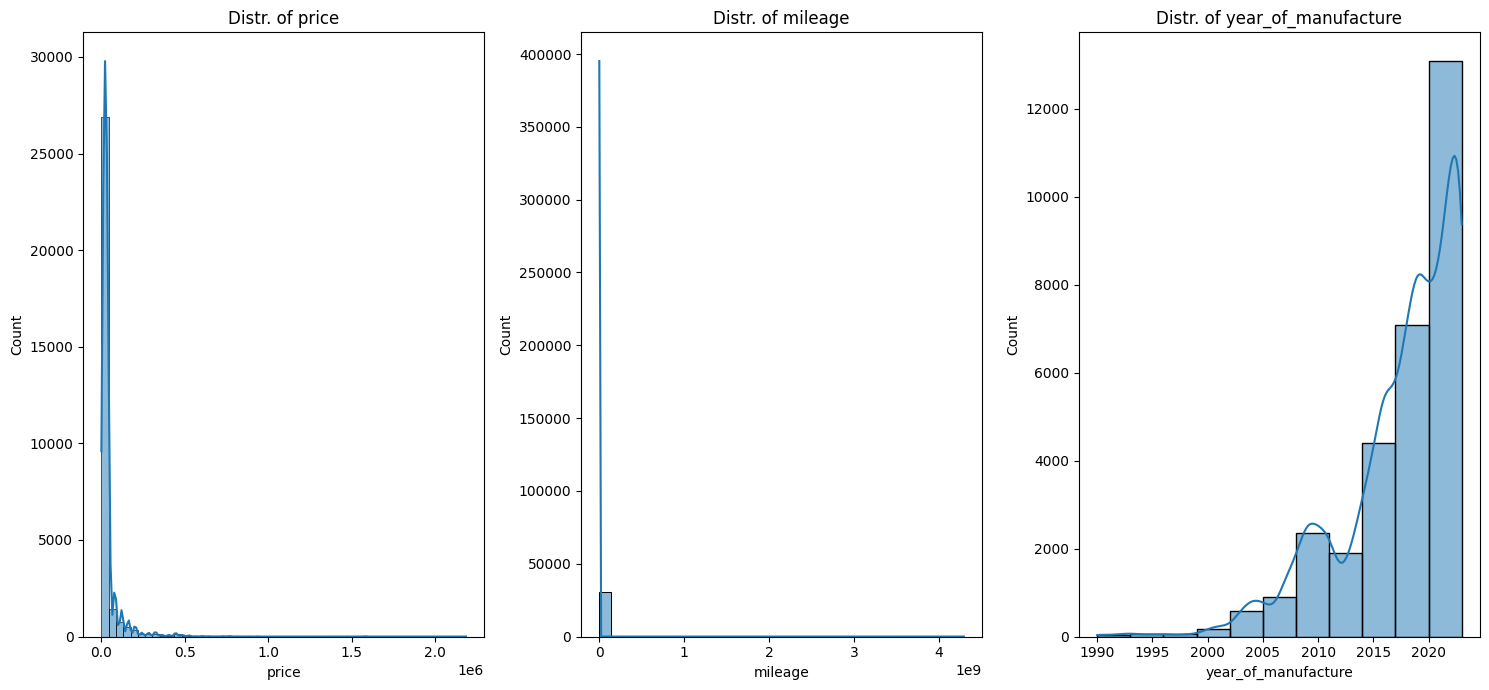

In [ ]:
## visualising data distribution
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1,3,figsize=(15,7))
num = 0

for col in car_stats_data:

  if col == 'price':
    bin_size = 50
  elif col == 'mileage':
    bin_size = 30
  elif col == 'year_of_manufacture':
    bin_size = 11


  sns.histplot(
      data=car_stats_data,
      x=col,
      bins= bin_size,
      kde=True,
      ax=axes[num]
  )

  axes[num].set_title(f"Distr. of {col}")
  num+=1

plt.tight_layout()
plt.show()


### interpretation and explanation of numerical values


### `price`:
#### Measures of Centeral Tendency:
the mean is noticeably larger than the median, which suggests a positively skewed distribution. Large values may also increase the mean. the mode is similar to the mean, which suggests that the mode being relatively high, suggests a common cluster of prices around $46 thousand, despite the median being lower.  

#### Measure of Variability:
the standard deviation is almost double the mean, which suggests high dispersion and likely non-normal, skewed or heterogenous data. This also suggests the mean is not a suitable measure of central tendency.
the large range may be due to a positively skewed distribution or due to an extreme observation.

#### Interquartile Range:
the median was 25 thousand, with the middle 50% of observations lying between 16 thousand and 40 thousand.

#### Histogram analysis
It is observed that most values are clustered on the left hand side. the positve skewedness is due to extreme values, that are stretching the x-axis. Further filtering of data will be required in order to accurately observe skewdness.

### `mileage`:
#### Measures of Centeral Tendency:
the mean is noticeably larger than the median, which suggests a positively skewed distribution. Large values may also increase the mean. the mode is 0, which is noticeably smaller than both the mean and median. the higher mean suggests that cars with higher mileage may be extending the upper end of the distribution.

#### Measure of Variability:
the mean is similar to the median, which suggest that the data is positively skewed, with extreme upper values.
the large range may be due to a positively skewed distribution or due to an extreme observation.

#### Interquartile Range:
the median was 20 thousand, with the middle 50% of observations lying between 0 and 60 thousand. with a maximum number of 4.2 billion, this strongly indicates towards a positive distribution, with extreme values at the tail possibly being outliers.

#### Histogram analysis
extreme values are present, that are stretching the x-axis. Further filtering of data will be required in order to accurately observe skewdness. However, it is observed that majority of cars do not have any mileage.


### `year_of_manufacture`:
#### Measures of Centeral Tendency:
the median is larger than the mean by 2 years, which suggest a negatively skewed distribution. The mode is noticeably larger than the mean and median, which indicates that older cars may be extending the lower end of the distribution.

#### Measure of Variability:
the standard deviation is relatively small, which indicates that the observations are concentrated around the mean. which is standard in terms of time in years, especially since cars are a newer invention, and the dataset itself only has a range of 33 years, with older cars stretching the lower tail.

#### Interquartile Range:
The median was 2019, with the middle 50% being manufactured between 2015 and 2022

#### Histogram Analysis
The histogram displays left-skewedness, which displays a high amount of newer cars, and a few older ones dating back to 1990.

## b. Outliers and Missing Values

In [ ]:
before = len(car_data)

#### Check Duplicate Rows

In [ ]:
## Check Duplicate records
print("number of duplicate rows:")
display(car_data.duplicated().sum())

## no duplicate rows were identified

number of duplicate rows:


np.int64(0)

#### Check for impossible or invalid values

The lowest 300 price values were inspectd after sorting the variable in ascending order. A clear error in the data was identified. The lowest prices were recorded to be between 4.05e-05 to 0.008097184, which are highly unrealistic values for a car. The value then jumps to 728.746562, which is low, but a realistic pricepoint for a car.

therefore, any values below 1 will be classified as invalid and treated as missing values

In [ ]:
# Check for impossible or invalid values

## the 'price' it has been observed that the value jumps from 0.008097184 to 728.746562.
#for value in car_data.nsmallest(200, "price")["price"]:
#    print(repr(value))

## setting invalid 'price' values to NA

car_data["price"] = car_data["price"].mask(
    car_data["price"] < 1,
    pd.NA
)

In [ ]:
# 'mileage' contains unrealistically high values
#for value in car_data.nlargest(300, "mileage")["mileage"]:
#    print(repr(value))

# mileage: anything above 500,000 km is not realistic for any car - cap it
car_data["mileage"] = car_data["mileage"].mask(
    car_data["mileage"] > 500000,
    pd.NA
)


#### i. detect and remove outliers
Detect outliers using the IQR method and justify whether each outlier should
be removed, retained, or transformed.

The IQR method concluded that approximately 78.5% of records contained no outliers, while only 0.63% contained three or more outliers. Records containing more than three missing attributes were removed to avoid relying heavily on imputed values within a single observation. Records with one to three missing attributes were retained so that most of the original information could be preserved and the missing values imputed.

Following outlier treatment, standard deviations decreased across all numerical values, this indicates that extreme observations heavily contributed to the original variability.

The mathematical formulas were referenced from NIST statistics handbook 7.1.6

In [ ]:
# i. Detect Outliers

## calculating percentiles
Q1 = car_data[numerical_data].quantile(0.25)
Q3 = car_data[numerical_data].quantile(0.75)

## Calculate IQR
IQR_values = Q3 - Q1

## calculating extreme outliers thresholds
extreme_lower_limit = Q1 - (3 * IQR_values)
extreme_upper_limit = Q3 + (3 * IQR_values)

## identifying outliers using IQR limits
outliers = (
    (car_data[numerical_data] < extreme_lower_limit) |
    (car_data[numerical_data] > extreme_upper_limit)
)

## analyse the outlier distribution in each variable
variable_outlier_count = outliers.sum()
outlier_percentage = (outliers.mean() * 100)
outlier_summary = pd.DataFrame({
    'count': variable_outlier_count,
    'percentage': outlier_percentage
})
print(outlier_summary)

## count outliers in each record
record_outlier_count = outliers.sum(axis=1)

display(record_outlier_count.value_counts().sort_index())
## results: 0 outliers=27500; 1 outlier=2788; 2 outliers=343; 3 outliers= 21

## remove records with more than 1 outlier
filtered_car_data = car_data[record_outlier_count <= 1].copy()

## overall only 364 records were removed.

## replace remaining outlier cells with NA
filtered_car_data[numerical_data] = (
    filtered_car_data[numerical_data].mask(
        outliers.loc[filtered_car_data.index],
        pd.NA
        )
    )

                     count  percentage
mileage                185       0.604
num_of_doors            77       0.251
seating_capacity       166       0.542
fuel_consumption       145       0.473
year_of_manufacture     70       0.228
price                 2363       7.709
engine_capacity        367       1.197


,count
0,27657
1,2638
2,336
3,21


#### ii. Identify and treat missing values across the dataset.

 Choose appropriate
methods for imputation (mean, median, mode, or predictive modeling) based
on the variable type. Students must justify why the selected imputation
method is appropriate for each variable. Remember to show how you deal
with the outliers and missing values. The results before and after should also
be included. E.g.,
Before cleaning data: 150000 rows. After cleaning data: 113452 rows

#### Check for, and remove excessive missing data

Removing records with three or more missing values caused only minor changes to the mean and standard deviation of most numerical variables, but reduced a large number of usable obervations. Therefore, the threshold was considered excessive and was reduced to four or more missing values.

before cleaning data: 30652 rows

after cleaning data: 29300 rows

total difference: 1352 rows

number of missing values in each row


,count
0,5416
1,5642
2,16453
3,2594
4,188
5,2


,0
mileage,265
num_of_doors,5
seating_capacity,49
fuel_system,20874
fuel_consumption,16337
year_of_manufacture,38
price,461
engine_capacity,519


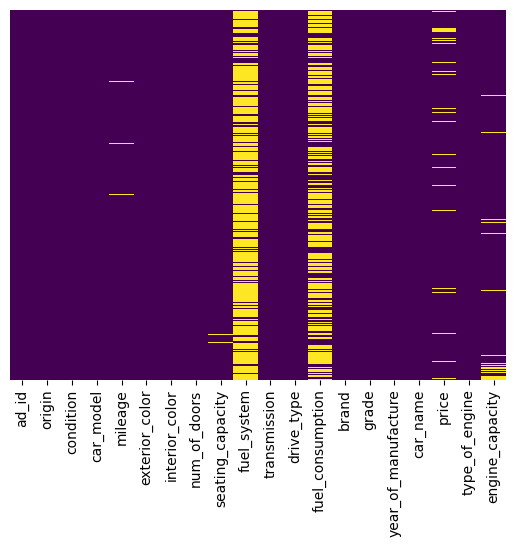

In [ ]:
## visualise null data
sns.heatmap(filtered_car_data.isnull(),cbar=False,yticklabels=False,cmap='viridis')

# count missing values in each record
data_isnull_count = filtered_car_data.isnull().sum(axis=1)

print("number of missing values in each row")
display(data_isnull_count.value_counts().sort_index())

## remove records with more than 3 missing values
filtered_car_data = filtered_car_data[data_isnull_count < 3].copy()

# select columns containg missing values
missing = filtered_car_data.isna().sum()
missing[missing > 0]

In [ ]:
after = len(filtered_car_data)

print("before:", before)
print("after:", after)
print("difference:", before - after)

print("")
## final comparison of mean and standard deviation
comparison = pd.DataFrame({
    "Change in Mean":  round((filtered_car_data[numerical_data].mean())
    - (car_data[numerical_data].mean()),2),
    "Change in Std":  round((filtered_car_data[numerical_data].std())
    - (car_data[numerical_data].std()),2)
})

print("Change in Mean and Standard Deviation after outlier removal")
display(comparison)

before: 30652
after: 27511
difference: 3141

Change in Mean and Standard Deviation after outlier removal


,Change in Mean,Change in Std
mileage,-328.270,-5300.130
num_of_doors,0.020,-0.370
seating_capacity,-0.040,-0.470
fuel_consumption,-28.490,-2093.560
year_of_manufacture,-0.050,-0.110
price,-16295.560,-62373.070
engine_capacity,-0.120,-0.200


## Imputation of valid missing values

for this investigation, the median value will be used to replace float and Integer types, this data is highly skewed so the median is safer in comparison to using the mean, which is more suitable for a normal distrubution. For Boolean and Categorical, the mode will be used.

However, it is achknowledged that various limitations exist with using median and mode for imputation. These include: Distortion of relationships, reduction of variance and ignored uncertainty. More advanced and accurate methods include regression imputation or K-Nearest Neighbours imputation (Thor, 2026).





In [ ]:
from sklearn.impute import SimpleImputer

In [ ]:
## fuel system contains too many missing values to impute reliably
filtered_car_data["fuel_system"] = car_data['fuel_system'].fillna('unknown')

## categorical - use mode
categorical_imputer = SimpleImputer(strategy="most_frequent", missing_values=pd.NA)

filtered_car_data[categorical_data] = categorical_imputer.fit_transform(filtered_car_data[categorical_data])


## convert back to string
filtered_car_data[categorical_data] = filtered_car_data[categorical_data].astype("string")

In [ ]:
## numerical - use median
numerical_imputer = SimpleImputer(strategy="median")

filtered_car_data[numerical_data] = numerical_imputer.fit_transform(filtered_car_data[numerical_data])
## restore integer columns
filtered_car_data[int_data] = filtered_car_data[int_data].round().astype("Int64")

In [ ]:
## check for missing values
missing = filtered_car_data.isna().sum()
missing[missing > 0]
## result = 0 !

,0


# Data Visualization

### 4a. Static Visualisation
#### ia. Examine the relationship between `mileage` and `price`.

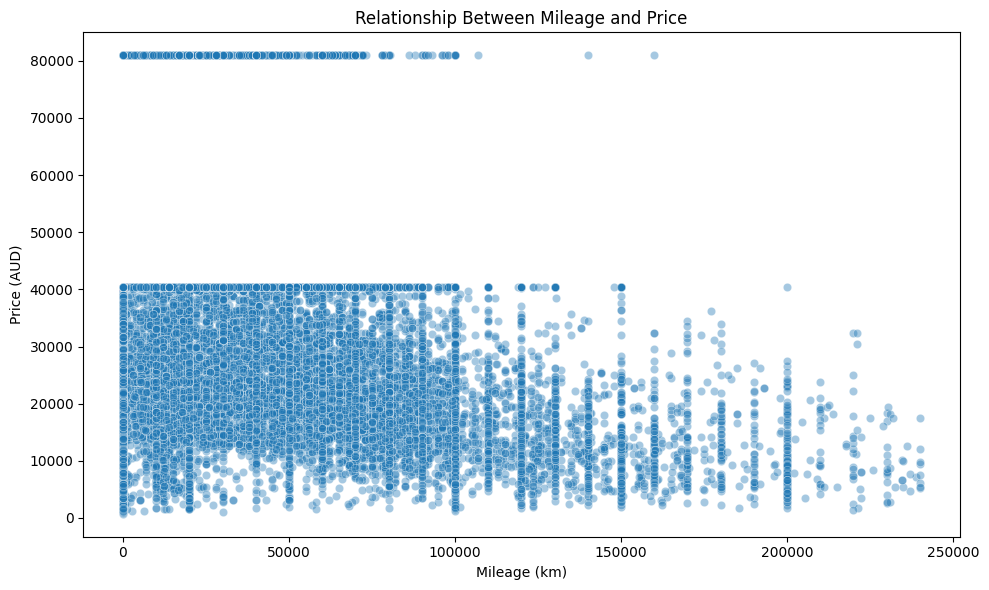

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6)) #controls size of chart
sns.scatterplot(data=filtered_car_data, x='mileage', y='price', alpha=0.4) #tells searborn what data to pull from
plt.title('Relationship Between Mileage and Price') #labels titles/ axis
plt.xlabel('Mileage (km)')
plt.ylabel('Price (AUD)')
plt.tight_layout()
plt.show() #show the graph

ib. Analyse the trend of car
prices over the `year_of_m`

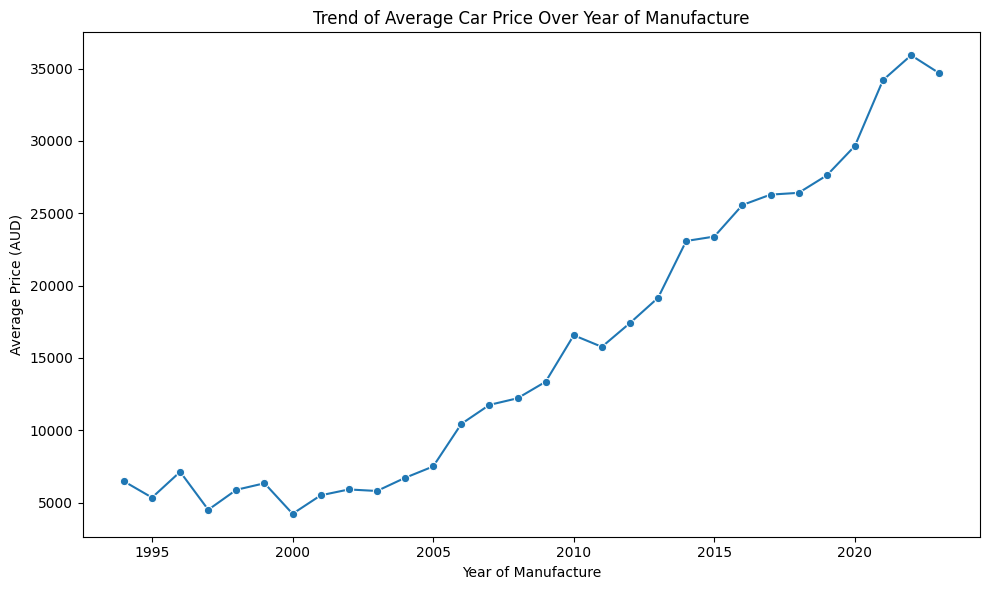

In [ ]:
yearly_avg_price = filtered_car_data.groupby('year_of_manufacture')['price'].mean().reset_index() # crunches the numbers

plt.figure(figsize=(10, 6)) #size of graph
sns.lineplot(data=yearly_avg_price, x='year_of_manufacture', y='price', marker='o') #what data to use where
plt.title('Trend of Average Car Price Over Year of Manufacture') #titles and axis labels
plt.xlabel('Year of Manufacture')
plt.ylabel('Average Price (AUD)')
plt.tight_layout()
plt.show() #show table

#### ii. Compare the average prices among different `car_models`


/tmp/ipykernel_23792/4058396179.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=avg_price_by_model, x='car_model', y='price', palette='viridis') #what data to use wehre, applies general visualisation tools to look nice


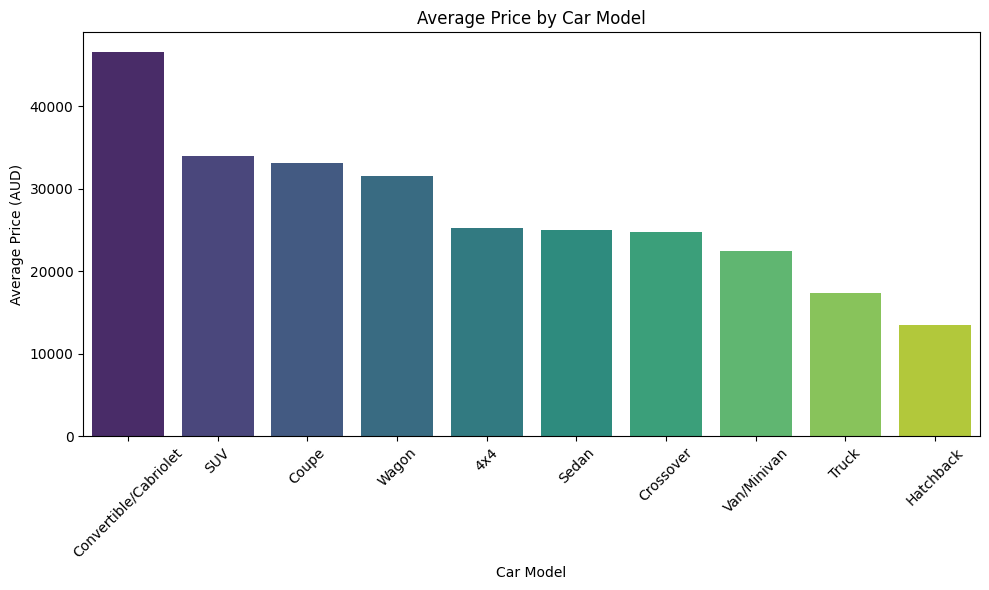

In [ ]:
avg_price_by_model = filtered_car_data.groupby('car_model')['price'].mean().sort_values(ascending=False).reset_index() #groups cars by model and calculates average for each

plt.figure(figsize=(10, 6)) #size of graph
sns.barplot(data=avg_price_by_model, x='car_model', y='price', palette='viridis') #what data to use wehre, applies general visualisation tools to look nice
plt.title('Average Price by Car Model') #lables
plt.xlabel('Car Model')
plt.ylabel('Average Price (AUD)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show() #show table

#### iii. Display the distribution of `engine_capacity`.

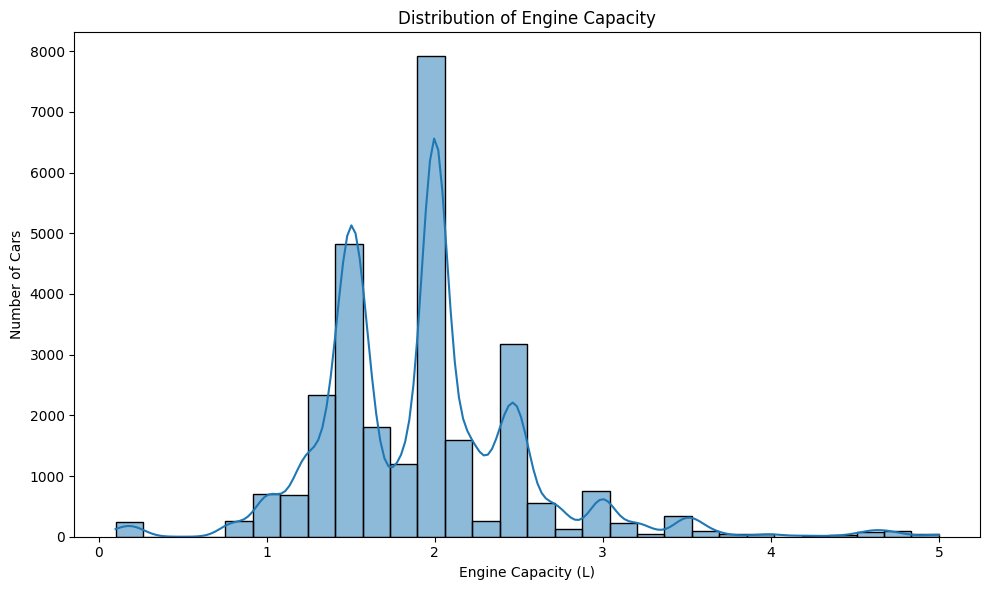

In [ ]:
plt.figure(figsize=(10, 6)) # graph size
sns.histplot(data=filtered_car_data, x='engine_capacity', bins=30, kde=True) #what graph, data type, general cleaning up of graph
plt.title('Distribution of Engine Capacity') #titles and lables
plt.xlabel('Engine Capacity (L)')
plt.ylabel('Number of Cars')
plt.tight_layout()
plt.show() #show graph

#### iv. Visualise the distribution of the cars’ exterior colors as the percentage of a whole.

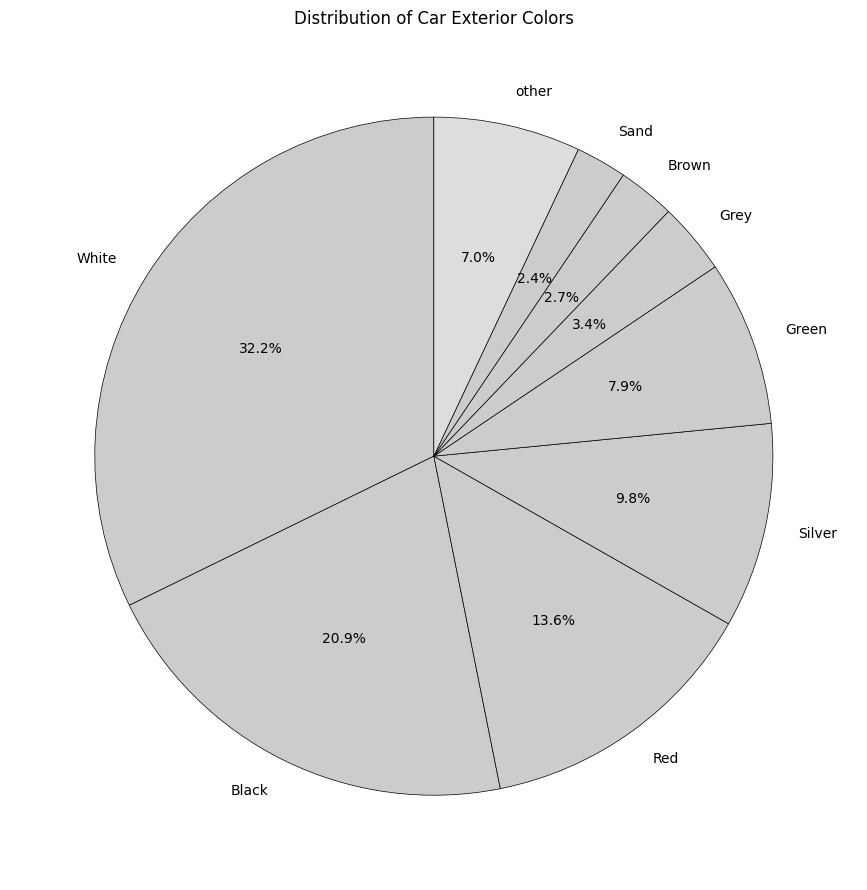

In [ ]:
valid_colors = filtered_car_data[~filtered_car_data['exterior_color'].isin(['take note', 'different color', '-'])] # filters data with junk values removed
color_counts = valid_colors['exterior_color'].value_counts() # counts and sorts each car colour

# stores 8 slices so can be changed later, pulls the top 8 colours to display seperately
top_n = 8
top_colors = color_counts.head(top_n).copy()
other_total = color_counts.iloc[top_n:].sum()
top_colors['other'] = other_total # every colour after top 8 gets put into seperate "other" category

def autopct_format(pct):
    return f'{pct:.1f}%' if pct > 2 else '' # how to label each slice

# ensure each colour is represented by the colour name in the graph (blue is shown as blue and so forth)
color_map = {
    'white': '#FFFFFF',
    'black': '#000000',
    'red': '#D62728',
    'silver': '#C0C0C0',
    'green': '#2CA02C',
    'grey': '#808080',
    'brown': '#8B4513',
    'sand': '#C2B280',
    'yellow': '#FFD700',
    'orange': '#FF8C00',
    'other': '#DDDDDD'
}

slice_colors = [color_map.get(color, '#CCCCCC') for color in top_colors.index]


plt.figure(figsize=(9, 9)) # difines plot area
plt.pie(
    top_colors,
    labels=top_colors.index,
    autopct=autopct_format,
    startangle=90,
    colors=slice_colors,
    wedgeprops={'edgecolor': 'black', 'linewidth': 0.5}
) # pulls data, now using slice_colors so each slice matches its real colour
plt.title('Distribution of Car Exterior Colors') #labels
plt.tight_layout()
plt.show() #shows table

#### v. Visualise/Identify correlations between these features: `mileage`,`num_of_doors`, `seating_capacity`, `fuel_consumption`, and `price`.

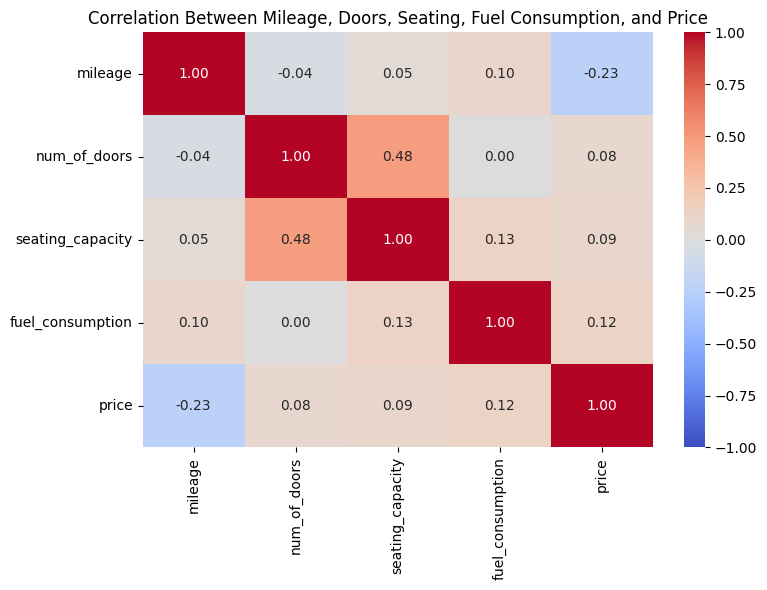

In [ ]:
correlation_cols = ['mileage', 'num_of_doors', 'seating_capacity', 'fuel_consumption', 'price'] # lists 5 collumns we want displayed
correlation_matrix = filtered_car_data[correlation_cols].corr() # calculation

plt.figure(figsize=(8, 6)) #plot size
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1) #turns grid into colour coded map
plt.title('Correlation Between Mileage, Doors, Seating, Fuel Consumption, and Price') # labels graph
plt.tight_layout()
plt.show() # shows table

### b. interactive visuals

plotly has been used instead of Matplotlib/Seaborn, due to its highly interactive visualisations

#### i. Relationship analysis between 'mileage' and 'price'

hovering over a point displays an overview of the car


In [ ]:
import plotly.express as px

fig = px.scatter(
    car_data,
    x = 'mileage',
    y = 'price',
    title = 'relationship between mileage and price',
    labels = {'mileage': "Mileage (km)",'price': "Price (AUD)"},
    hover_data = ['car_model', 'year_of_manufacture'],
    color = 'car_model'
)

fig.show()

#### ii. trend of car prices over the `year_of_m`

In [ ]:
fig2 = px.line(
    yearly_avg_price,
    x = 'year_of_manufacture',
    y = 'price',
    markers = True,
    title="Trend of Average Car Price Over Year of Manufacture",
    labels={'price':'average price (AUD)', 'year_of_manufacture':'year of manufacture'}
)

## allows user to select a horizontal/vertical zoom
fig2.update_layout(
    xaxis_rangeslider_visible = True
)

fig2.show()